## Estudiante
Tayron Cuellar

# Clasificación de gatos y perros

Este notebook está escrito como una lectura guiada, no como una lista de celdas sueltas. La idea es que cualquier persona pueda seguirlo desde cero, entender qué hace cada bloque y ver cómo los gráficos cuentan la historia del modelo.

Primero se descarga y organiza el dataset. Después se prepara la información, se construye la red neuronal, se entrena el modelo y se revisa su desempeño con gráficos fáciles de interpretar. Al final se deja una sección interactiva para subir una imagen y pedirle al modelo que diga si parece un gato o un perro.

La meta no es solo entrenar una CNN, sino dejar un notebook claro, visual y explicativo, con el estilo de una revista técnica.

In [4]:
import io
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import keras
from IPython.display import display
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import ipywidgets as widgets

warnings.filterwarnings('ignore')

SEED = 42
IMG_SIZE = (128, 128)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

layers = keras.layers

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
print('Configuración lista.')

Configuración lista.


## 1. Preparación del entorno

En esta celda se cargan las librerías que usará el notebook y se fijan los valores globales de trabajo: tamaño de imagen, tamaño de lote y semilla aleatoria. También se activa un estilo visual más limpio para que los gráficos sean fáciles de leer.

La semilla hace que el experimento sea más reproducible. Si se vuelve a ejecutar el notebook, el orden de muchas operaciones será parecido y los resultados serán más consistentes.

In [5]:
try:
    import kagglehub
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'kagglehub'])
    import kagglehub

dataset_path = Path(kagglehub.dataset_download('bhavikjikadara/dog-and-cat-classification-dataset'))
print('Ruta del dataset:', dataset_path)
print('Existe:', dataset_path.exists())

Ruta del dataset: C:\Users\Tayron\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\versions\1
Existe: True


## 2. Descarga del dataset

Aquí se obtiene el dataset desde Kaggle Hub y se guarda en una ruta local. La ventaja de este enfoque es que el notebook puede reutilizar la caché descargada y evitar bajar todo de nuevo en cada ejecución.

Si la ruta existe, ya podemos trabajar directamente con los archivos de imagen sin depender de una descarga repetida.

Muestras encontradas: 24998


,filepath,label,split,label_idx
0,C:\Users\Tayron\.cache\kagglehub\datasets\bhav...,gato,all,0
1,C:\Users\Tayron\.cache\kagglehub\datasets\bhav...,gato,all,0
2,C:\Users\Tayron\.cache\kagglehub\datasets\bhav...,gato,all,0
3,C:\Users\Tayron\.cache\kagglehub\datasets\bhav...,gato,all,0
4,C:\Users\Tayron\.cache\kagglehub\datasets\bhav...,gato,all,0


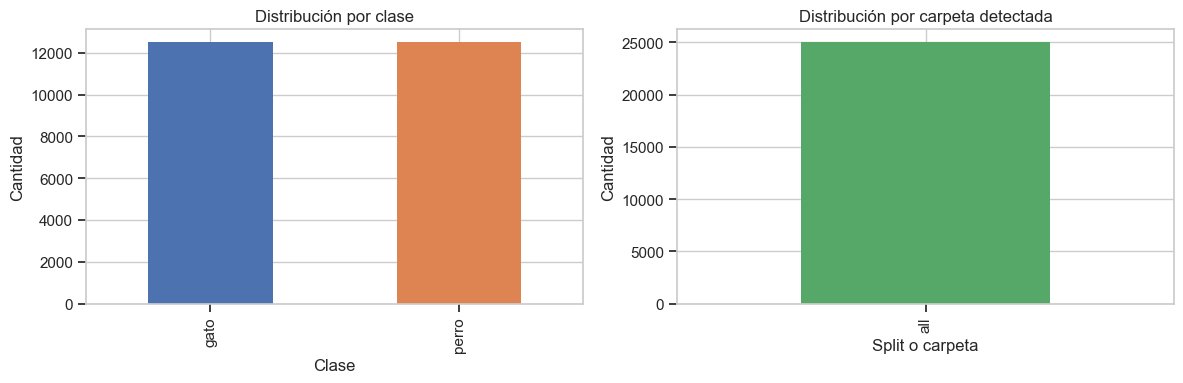

In [6]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
LABEL_ALIASES = {
    'cat': 'gato', 'cats': 'gato', 'gato': 'gato',
    'dog': 'perro', 'dogs': 'perro', 'perro': 'perro'
}
SPLIT_ALIASES = ['train', 'training', 'val', 'valid', 'validation', 'test']

def build_index(root_path):
    rows = []
    for file_path in root_path.rglob('*'):
        if file_path.suffix.lower() not in IMAGE_EXTS:
            continue
        parent_names = [parent.name.lower() for parent in file_path.parents]
        label = None
        for folder_name in parent_names:
            if folder_name in LABEL_ALIASES:
                label = LABEL_ALIASES[folder_name]
                break
        if label is None:
            continue
        split = 'all'
        for folder_name in parent_names:
            if folder_name in SPLIT_ALIASES:
                split = folder_name
                break
        rows.append({'filepath': str(file_path), 'label': label, 'split': split})
    index_df = pd.DataFrame(rows)
    if index_df.empty:
        raise ValueError('No se encontraron imágenes etiquetadas dentro del dataset.')
    index_df['label_idx'] = index_df['label'].map({'gato': 0, 'perro': 1}).astype('int32')
    return index_df

index_df = build_index(dataset_path)
print('Muestras encontradas:', len(index_df))
display(index_df.head())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
index_df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Distribución por clase')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')
index_df['split'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Distribución por carpeta detectada')
axes[1].set_xlabel('Split o carpeta')
axes[1].set_ylabel('Cantidad')
plt.tight_layout()

## 3. Lectura y organización de las imágenes

Esta celda recorre las carpetas del dataset, detecta los archivos de imagen y construye una tabla con tres columnas clave: ruta del archivo, etiqueta y partición detectada.

También se genera una vista rápida de cuántas imágenes hay por clase y por carpeta. Ese gráfico ayuda a entender si el dataset está balanceado y cómo viene organizado antes de entrenar la red.

In [7]:
split_values = set(index_df['split'].unique())
has_official_split = any(value in split_values for value in ['train', 'training', 'val', 'valid', 'validation', 'test'])

from sklearn.model_selection import train_test_split as _sk_train_test_split

def train_test_split(df, test_size, stratify, random_state):
    """Wrapper around sklearn.model_selection.train_test_split that returns DataFrames
    and resets indices for convenience."""
    train_df, test_df = _sk_train_test_split(
        df, test_size=test_size, stratify=stratify, random_state=random_state
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

if has_official_split:
    train_pool_df = index_df[index_df['split'].isin(['train', 'training'])].copy()
    val_df = index_df[index_df['split'].isin(['val', 'valid', 'validation'])].copy()
    test_df = index_df[index_df['split'].isin(['test'])].copy()

    if train_pool_df.empty:
        train_pool_df = index_df[index_df['split'] == 'all'].copy()

    if val_df.empty:
        train_df, val_df = train_test_split(
            train_pool_df,
            test_size=0.15,
            stratify=train_pool_df['label'],
            random_state=SEED,
        )
    else:
        train_df = train_pool_df

    if test_df.empty:
        train_df, test_df = train_test_split(
            train_df,
            test_size=0.15,
            stratify=train_df['label'],
            random_state=SEED,
        )
else:
    train_df, temp_df = train_test_split(
        index_df,
        test_size=0.30,
        stratify=index_df['label'],
        random_state=SEED,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df['label'],
        random_state=SEED,
    )

for df_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(df_name, len(df), df['label'].value_counts().to_dict())

class_names = ['gato', 'perro']
def _load_image_with_pil(path):
    image = Image.open(path.numpy().decode('utf-8')).convert('RGB')
    return np.asarray(image, dtype=np.uint8)


def load_image(path, label):
    image = tf.py_function(_load_image_with_pil, [path], Tout=tf.uint8)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    label = tf.reshape(label, [1])
    return image, label


def make_dataset(df, shuffle=False):
    paths = df['filepath'].values
    labels = df['label_idx'].values
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print('Muestras train/val/test:', len(train_df), len(val_df), len(test_df))
print('Datasets preparados.')

train 17498 {'perro': 8749, 'gato': 8749}
val 3750 {'perro': 1875, 'gato': 1875}
test 3750 {'perro': 1875, 'gato': 1875}
Muestras train/val/test: 17498 3750 3750
Datasets preparados.


## 4. Separación de datos y construcción de los lotes

Aquí se divide la información en entrenamiento, validación y prueba. El entrenamiento es lo que el modelo ve para aprender; la validación sirve para ajustar sin tocar el conjunto final; y la prueba queda reservada para medir el resultado de forma más honesta.

Después de la partición, las rutas de las imágenes se convierten en un pipeline de `tf.data` que carga cada archivo, lo transforma a RGB, lo redimensiona y lo entrega en lotes listos para la red neuronal.

In [8]:
def predecir_imagen_desde_array(image_array):
    image = tf.image.resize(image_array, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    prob = float(model.predict(image[None, ...], verbose=0)[0][0])
    label = 'perro' if prob >= 0.5 else 'gato'
    confidence = prob if prob >= 0.5 else 1 - prob
    return label, prob, confidence

# Esta función se reutiliza al final del notebook, donde sí se muestra la interfaz para subir una imagen.

## 6. Diseño de la red neuronal

Aquí se construye la CNN que aprenderá a distinguir gatos de perros. La red mezcla aumento de datos, convoluciones, normalización, activaciones `ReLU`, reducción espacial y capas densas al final.

La idea es que las primeras capas aprendan bordes y texturas, mientras que las últimas combinan esa información para producir una predicción binaria: gato o perro.

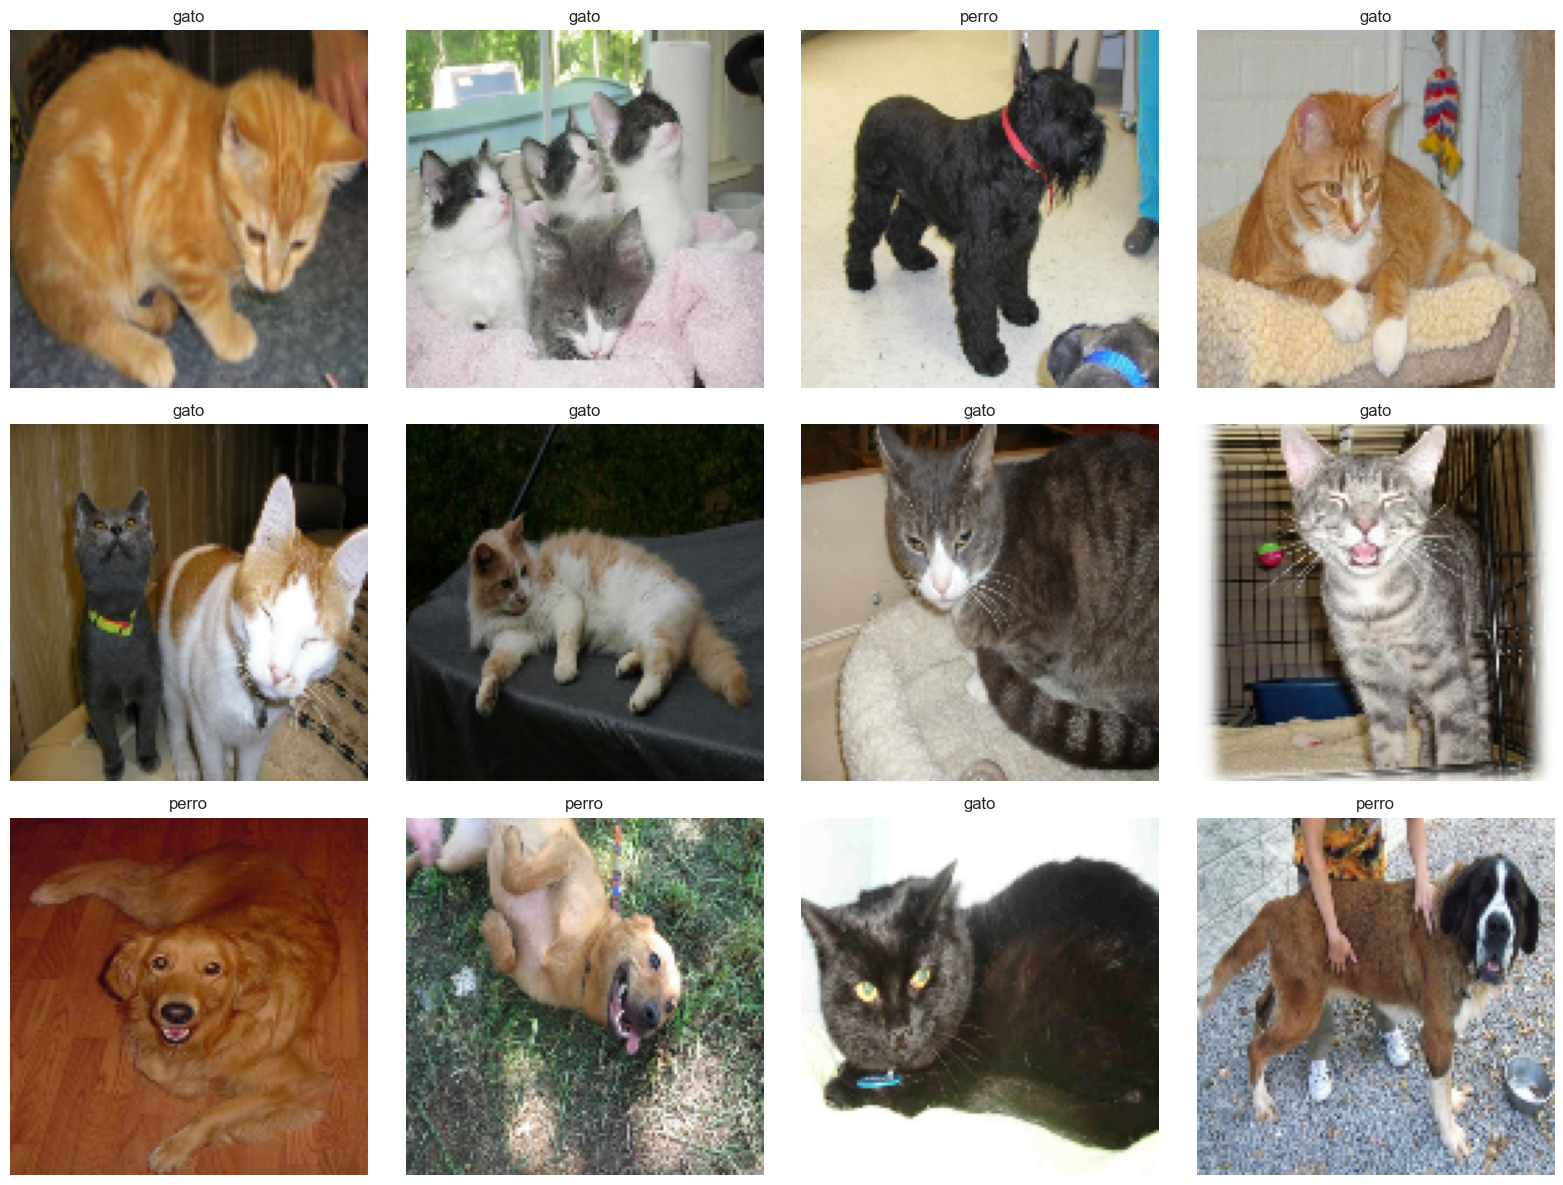

In [9]:
def mostrar_lote(dataset, n=12):
    images, labels = next(iter(dataset))
    n = min(n, images.shape[0])
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 4, rows * 4))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(np.clip(images[i].numpy().astype('uint8'), 0, 255))
        label_idx = int(labels[i].numpy().item())
        plt.title(class_names[label_idx])
        plt.axis('off')
    plt.tight_layout()

mostrar_lote(train_ds, n=12)

## 5. Mirar un lote de imágenes

Esta figura muestra varias imágenes reales del conjunto de entrenamiento. Sirve para comprobar que la carga funciona bien, que las etiquetas corresponden a lo esperado y que las imágenes llegan con un tamaño y una calidad razonables.

Justo después dejamos una función de inferencia reutilizable, que más adelante se conectará con la interfaz de subida de imágenes al final del notebook.

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='data_augmentation')

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1.0 / 255.0)(x)

for filtros in [32, 64, 128]:
    x = layers.Conv2D(filtros, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.20)(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.40)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs, name='cnn_gatos_perros')
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')],
)

model.summary()

Model: "cnn_gatos_perros"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,465 (400.25 KB)

 Trainable params: 102,017 (398.50 KB)

 Non-trainable params: 448 (1.75 KB)

## 7. Entrenamiento controlado

En esta celda el modelo aprende a partir de los lotes de entrenamiento y se valida con el conjunto de validación.

Los callbacks ayudan a entrenar mejor: `EarlyStopping` corta si el modelo deja de mejorar y `ReduceLROnPlateau` baja la tasa de aprendizaje cuando el progreso se estanca. Eso evita perder tiempo y ayuda a estabilizar el aprendizaje.

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 233s 840ms/step - accuracy: 0.6035 - auc: 0.6451 - loss: 0.6607 - val_accuracy: 0.5112 - val_auc: 0.6260 - val_loss: 0.7324 - learning_rate: 0.0010
Epoch 2/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 227s 827ms/step - accuracy: 0.6380 - auc: 0.6931 - loss: 0.6318 - val_accuracy: 0.6419 - val_auc: 0.7026 - val_loss: 0.6205 - learning_rate: 0.0010
Epoch 3/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 225s 819ms/step - accuracy: 0.6641 - auc: 0.7241 - loss: 0.6114 - val_accuracy: 0.5339 - val_auc: 0.6824 - val_loss: 0.9853 - learning_rate: 0.0010
Epoch 4/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 781ms/step - accuracy: 0.6773 - auc: 0.7384 - loss: 0.5985
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
274/274 ━━━━━━━━━━━━━━━━━━━━ 224s 819ms/step - accuracy: 0.6851 - auc: 0.7494 - loss: 0.5895 - val_accuracy: 0.5968 - val_auc: 0.6575 - val_loss: 0.8002 - learning_rate: 0.0010
Epoch 5/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 224s 818ms/step - accuracy: 0.7129 - auc: 0.78

## 8. Curvas de aprendizaje

Estos gráficos muestran cómo evolucionan la exactitud y la pérdida en entrenamiento y validación a lo largo de las épocas.

Si ambas curvas se acercan y se estabilizan, el modelo está aprendiendo de forma razonable. Si la curva de validación se separa mucho de la de entrenamiento, eso suele ser una señal de sobreajuste.

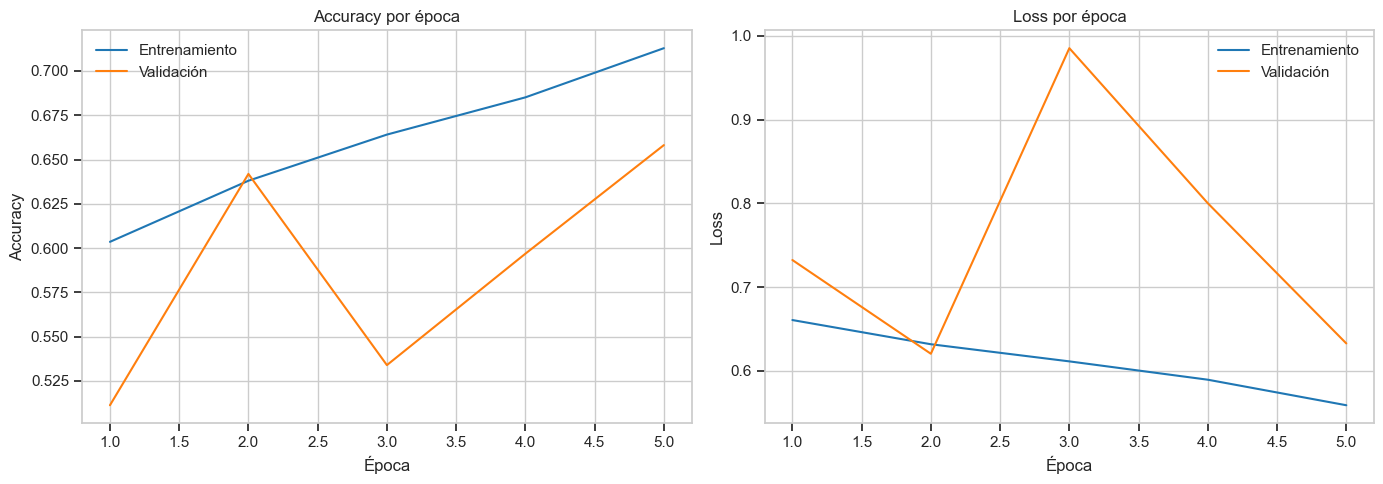

In [12]:
def plot_history(history_obj):
    history_dict = history_obj.history
    epochs = range(1, len(history_dict['loss']) + 1)
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_dict['accuracy'], label='Entrenamiento')
    plt.plot(epochs, history_dict['val_accuracy'], label='Validación')
    plt.title('Accuracy por época')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_dict['loss'], label='Entrenamiento')
    plt.plot(epochs, history_dict['val_loss'], label='Validación')
    plt.title('Loss por época')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()

plot_history(history)

## 9. Evaluación final

Aquí medimos el modelo en el conjunto de prueba, que el entrenamiento no ha visto. La matriz de confusión permite ver aciertos y errores por clase, mientras que la curva ROC resume el comportamiento del clasificador en distintos umbrales.

Esta parte es la que mejor responde si el modelo generaliza bien o si solo memoriza el entrenamiento.

Accuracy de test: 0.6581
              precision    recall  f1-score   support

        gato     0.6298    0.7675    0.6918      1875
       perro     0.7024    0.5488    0.6162      1875

    accuracy                         0.6581      3750
   macro avg     0.6661    0.6581    0.6540      3750
weighted avg     0.6661    0.6581    0.6540      3750



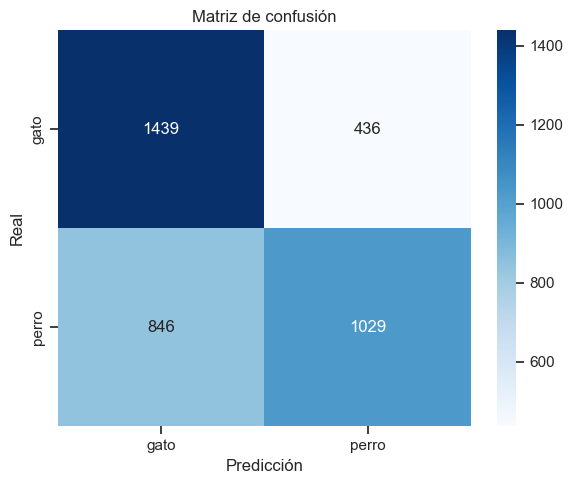

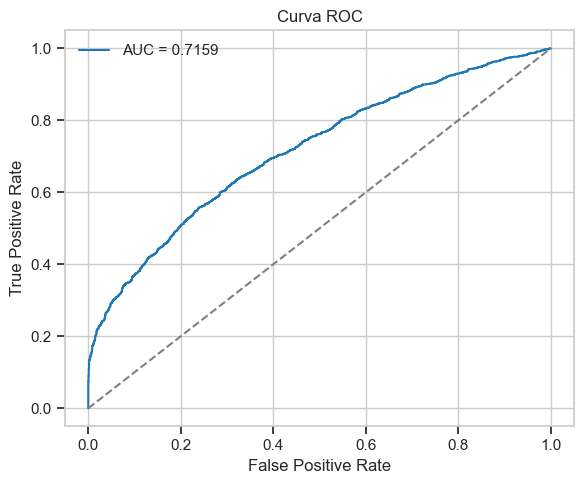

In [13]:
test_probs = model.predict(test_ds, verbose=0).ravel()
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0).astype(int).ravel()
y_pred = (test_probs >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
accuracy_test = (y_true == y_pred).mean()
print(f'Accuracy de test: {accuracy_test:.4f}')
print(report)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión')
plt.tight_layout()

fpr, tpr, _ = roc_curve(y_true, test_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.tight_layout()

## 10. Ejemplos correctos e incorrectos

Ver imágenes concretas ayuda a interpretar la evaluación. En vez de mirar solo métricas agregadas, aquí se ven ejemplos donde el modelo acertó y otros donde falló.

Eso permite detectar patrones visuales: perros muy similares a gatos, imágenes borrosas, fondos complejos o poses poco comunes.

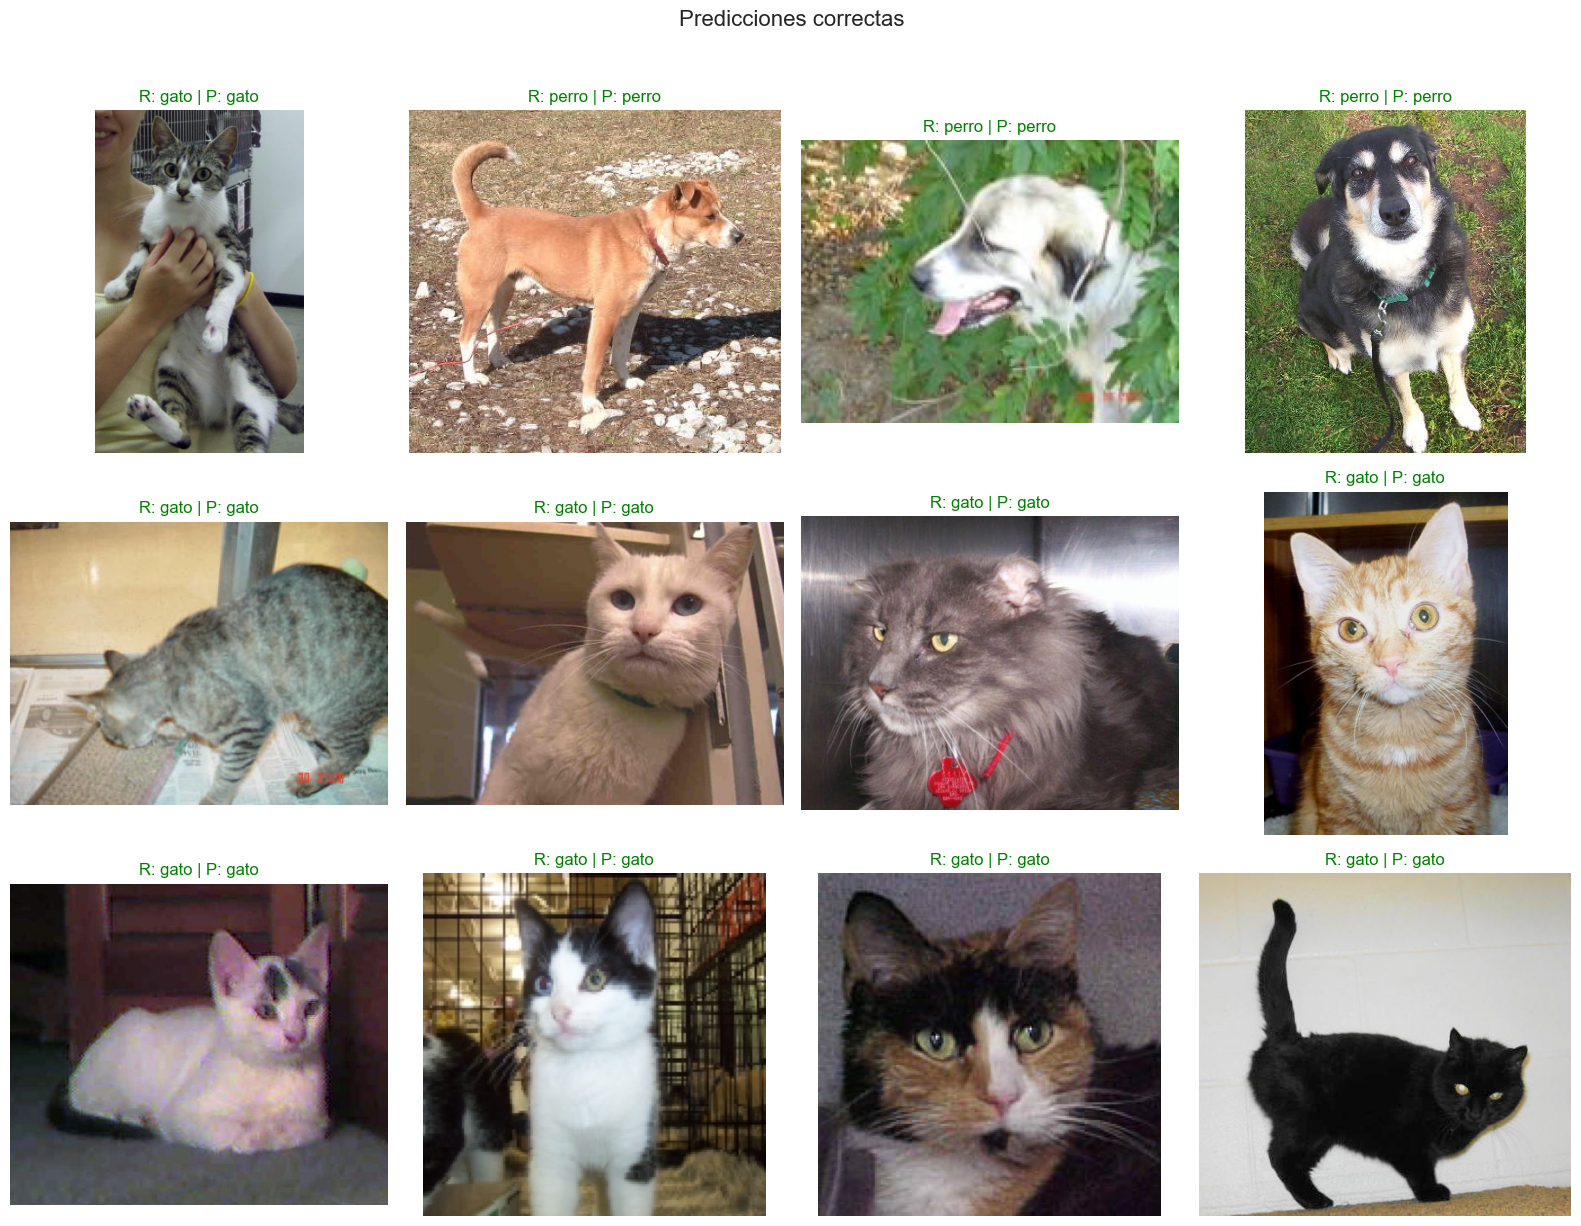

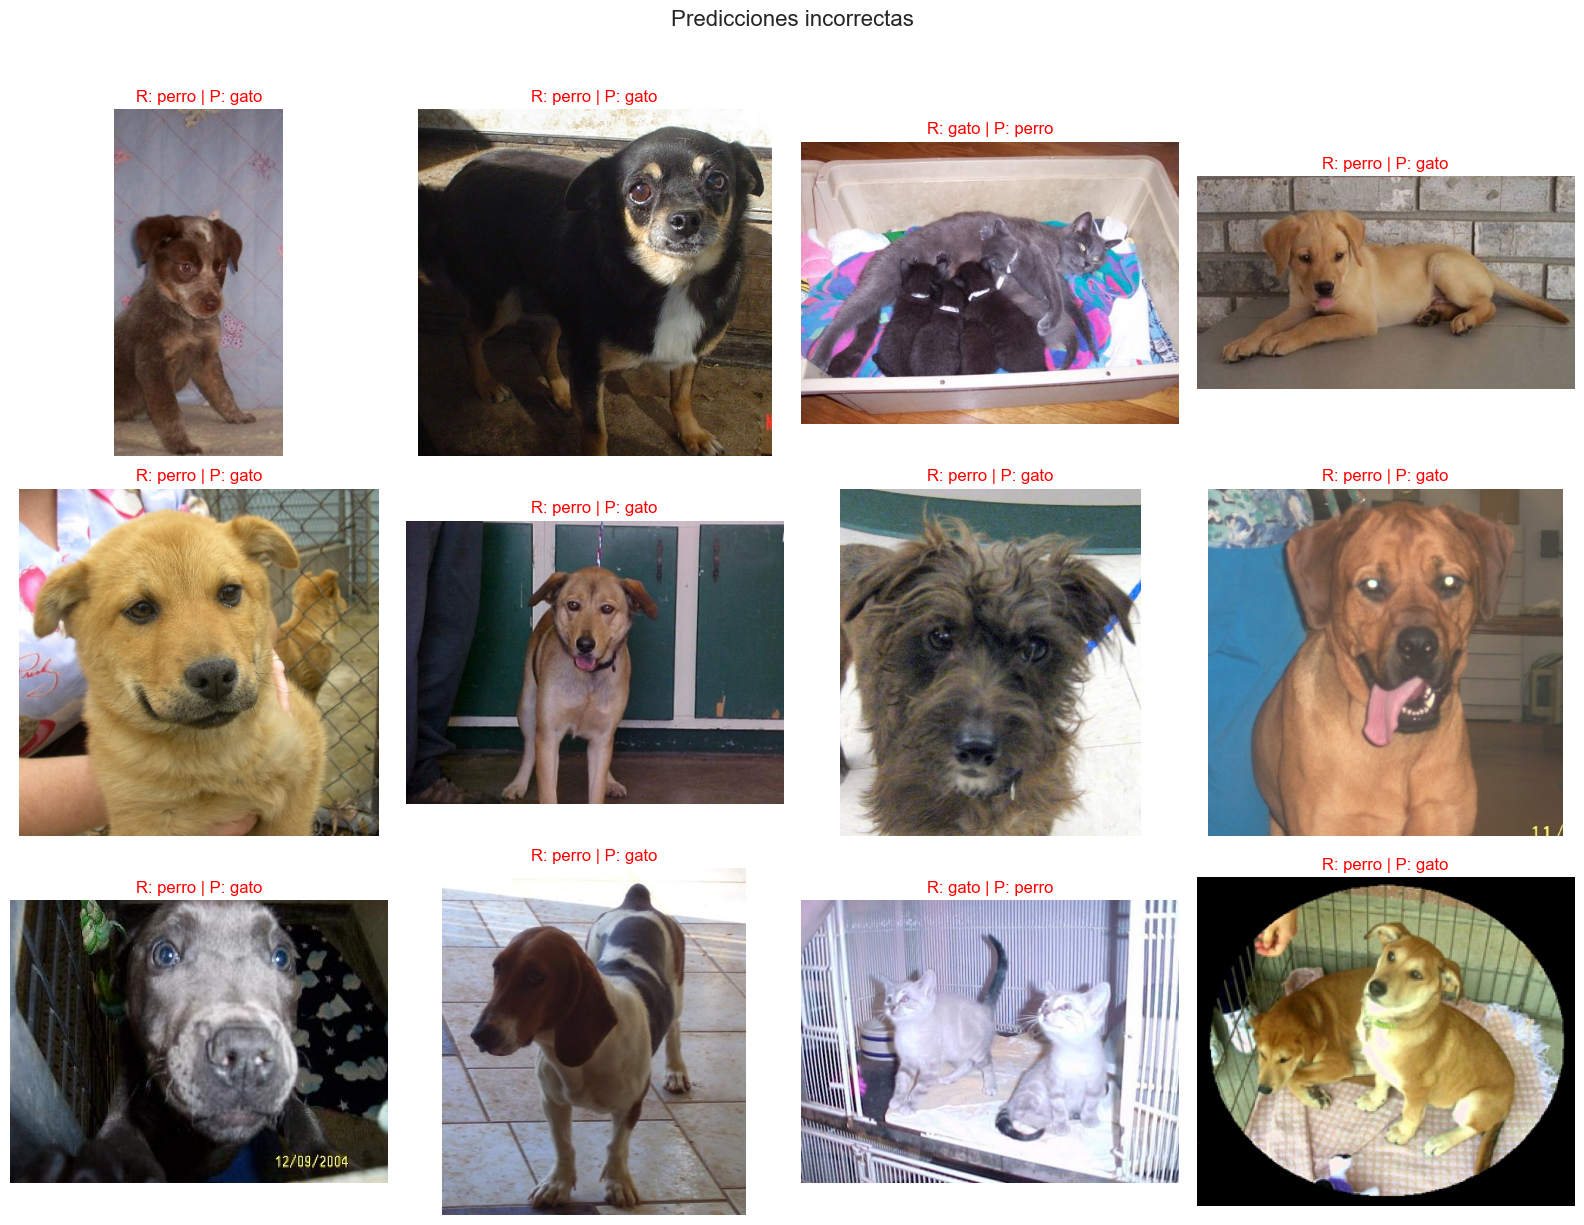

In [14]:
test_paths = test_df['filepath'].values

def mostrar_ejemplos(indices, titulo, max_ejemplos=12):
    indices = list(indices)[:max_ejemplos]
    if len(indices) == 0:
        print(f'No se encontraron ejemplos para: {titulo}')
        return
    cols = 4
    rows = int(np.ceil(len(indices) / cols))
    plt.figure(figsize=(cols * 4, rows * 4))
    for i, idx in enumerate(indices):
        plt.subplot(rows, cols, i + 1)
        img = Image.open(test_paths[idx]).convert('RGB')
        plt.imshow(img)
        real = class_names[y_true[idx]]
        pred = class_names[y_pred[idx]]
        color = 'green' if y_true[idx] == y_pred[idx] else 'red'
        plt.title(f'R: {real} | P: {pred}', color=color)
        plt.axis('off')
    plt.suptitle(titulo, y=1.02, fontsize=16)
    plt.tight_layout()

mostrar_ejemplos(np.where(y_true == y_pred)[0], 'Predicciones correctas')
mostrar_ejemplos(np.where(y_true != y_pred)[0], 'Predicciones incorrectas')

## Conclusiones

El notebook deja el flujo completo para entrenar, evaluar y usar un clasificador de gatos y perros con una CNN desde cero. Si el rendimiento final no fuera suficiente, la siguiente mejora natural sería probar transfer learning, pero en esta versión se mantiene el enfoque más cercano al notebook de referencia.

Debajo queda la sección interactiva final para subir una imagen externa y ver la predicción del modelo en vivo.

In [15]:
# Sección final interactiva: sube una imagen y el modelo dirá si parece gato o perro.
def _extraer_contenido_subido(uploaded_value):
    if isinstance(uploaded_value, dict):
        file_info = next(iter(uploaded_value.values()))
    elif isinstance(uploaded_value, (list, tuple)):
        file_info = uploaded_value[0]
    else:
        file_info = uploaded_value

    if isinstance(file_info, dict):
        content = file_info.get('content')
    else:
        content = getattr(file_info, 'content', None)

    if content is None:
        raise ValueError('No se pudo leer el archivo subido.')

    if hasattr(content, 'tobytes'):
        content = content.tobytes()

    return content


def clasificar_subida():
    uploader = widgets.FileUpload(accept='image/*', multiple=False)
    boton = widgets.Button(description='Clasificar imagen', button_style='primary')
    salida = widgets.Output()

    def predecir_local(image_array):
        image = tf.image.resize(image_array, IMG_SIZE)
        image = tf.cast(image, tf.float32)
        prob = float(model.predict(image[None, ...], verbose=0)[0][0])
        label = 'perro' if prob >= 0.5 else 'gato'
        confidence = prob if prob >= 0.5 else 1 - prob
        return label, prob, confidence

    def on_click(_):
        with salida:
            salida.clear_output()
            if not uploader.value:
                print('Sube una imagen primero.')
                return
            try:
                content = _extraer_contenido_subido(uploader.value)
                image = Image.open(io.BytesIO(content)).convert('RGB')
                image_array = tf.convert_to_tensor(np.array(image))
                label, prob, confidence = predecir_local(image_array)

                plt.figure(figsize=(6, 6))
                plt.imshow(image)
                plt.axis('off')
                plt.title(f'Predicción: {label} | confianza: {confidence:.2%}')
                plt.show()

                print(f'Probabilidad de perro: {prob:.4f}')
                print(f'Predicción final: {label}')
            except Exception as exc:
                print(f'No se pudo clasificar la imagen: {exc}')

    boton.on_click(on_click)
    display(widgets.VBox([widgets.HTML('<b>Sube una imagen externa para clasificarla</b>'), uploader, boton, salida]))

clasificar_subida()